<a href="https://colab.research.google.com/github/aetane18/er_wait-time/blob/main/Stats_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ER Wait Time Dataset.csv to ER Wait Time Dataset.csv


In [ ]:
df = pd.read_csv("ER Wait Time Dataset.csv")

df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

df.head()

,visit_id,patient_id,hospital_id,hospital_name,region,visit_date,day_of_week,season,time_of_day,urgency_level,nurse_to_patient_ratio,specialist_availability,facility_size_beds,time_to_registration_min,time_to_triage_min,time_to_medical_professional_min,total_wait_time_min,patient_outcome,patient_satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [ ]:
print("Shape:", df.shape)

df.info()

Shape: (5000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   visit_id                          5000 non-null   object
 1   patient_id                        5000 non-null   object
 2   hospital_id                       5000 non-null   object
 3   hospital_name                     5000 non-null   object
 4   region                            5000 non-null   object
 5   visit_date                        5000 non-null   object
 6   day_of_week                       5000 non-null   object
 7   season                            5000 non-null   object
 8   time_of_day                       5000 non-null   object
 9   urgency_level                     5000 non-null   object
 10  nurse_to_patient_ratio            5000 non-null   int64 
 11  specialist_availability           5000 non-null   int64 
 12  fa

In [ ]:
df.describe(include="all")

,visit_id,patient_id,hospital_id,hospital_name,region,visit_date,day_of_week,season,time_of_day,urgency_level,nurse_to_patient_ratio,specialist_availability,facility_size_beds,time_to_registration_min,time_to_triage_min,time_to_medical_professional_min,total_wait_time_min,patient_outcome,patient_satisfaction
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000
unique,5000,5000,5,5,2,5000,7,4,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,HOSP-1-20240825-0994,PAT-05000,HOSP-2,Riverside Medical Center,Urban,2024-08-25 23:05:40,Monday,Summer,Evening,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Discharged,NaN
freq,1,1,1023,1023,3006,1,768,1281,1725,1291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2879,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,NaN,2.771600
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,NaN,1.424584
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,NaN,3.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,NaN,4.000000


In [ ]:
df.isnull().sum()

,0
visit_id,0
patient_id,0
hospital_id,0
hospital_name,0
region,0
visit_date,0
day_of_week,0
season,0
time_of_day,0
urgency_level,0


In [ ]:
df["visit_date"] = pd.to_datetime(df["visit_date"])

df["month"] = df["visit_date"].dt.month
df["hour"] = df["visit_date"].dt.hour
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

df[["visit_date", "month", "hour", "is_weekend"]].head()

,visit_date,month,hour,is_weekend
0,2024-02-10 20:20:56,2,20,1
1,2024-11-28 02:07:47,11,2,0
2,2024-09-30 04:02:28,9,4,0
3,2024-02-27 00:31:13,2,0,0
4,2024-03-06 16:52:26,3,16,0


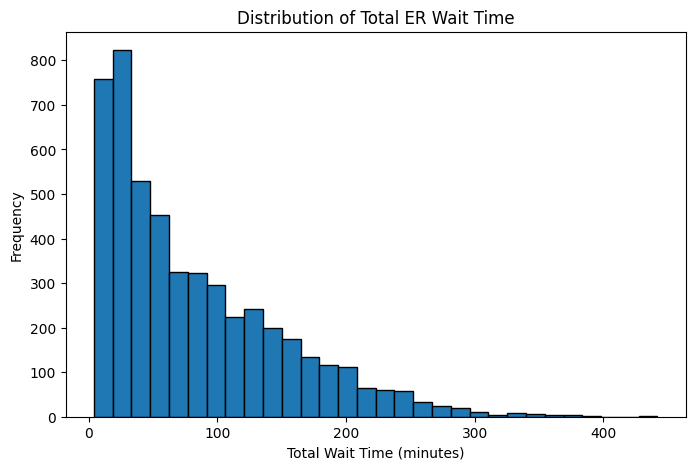

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["total_wait_time_min"], bins=30, edgecolor="black")
plt.title("Distribution of Total ER Wait Time")
plt.xlabel("Total Wait Time (minutes)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
urgency_wait = df.groupby("urgency_level")["total_wait_time_min"].mean().sort_values()

urgency_wait

,total_wait_time_min
urgency_level,
Critical,18.351047
High,43.187149
Medium,93.695585
Low,173.536825


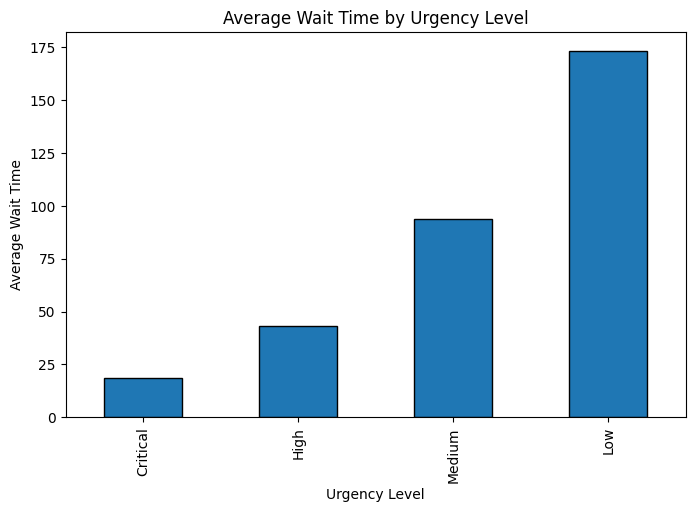

In [ ]:
plt.figure(figsize=(8, 5))
urgency_wait.plot(kind="bar", edgecolor="black")
plt.title("Average Wait Time by Urgency Level")
plt.xlabel("Urgency Level")
plt.ylabel("Average Wait Time")
plt.show()

In [ ]:
region_wait = df.groupby("region")["total_wait_time_min"].mean()

region_wait

,total_wait_time_min
region,
Rural,81.824473
Urban,81.977711


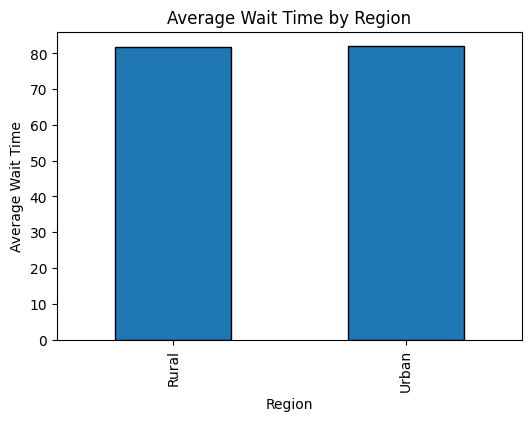

In [ ]:
plt.figure(figsize=(6, 4))
region_wait.plot(kind="bar", edgecolor="black")
plt.title("Average Wait Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Wait Time")
plt.show()

In [ ]:
population_mean = df["total_wait_time_min"].mean()
population_std = df["total_wait_time_min"].std()

print("Population Mean Wait Time:", population_mean)
print("Population Standard Deviation:", population_std)

Population Mean Wait Time: 81.9166
Population Standard Deviation: 68.08453822498223


In [ ]:
sample_size = 50
num_samples = 1000

sample_means = []

for i in range(num_samples):
    sample = df["total_wait_time_min"].sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print("Mean of Sample Means:", sample_means.mean())
print("Standard Error:", sample_means.std())

Mean of Sample Means: 81.91748000000001
Standard Error: 9.676820058758972


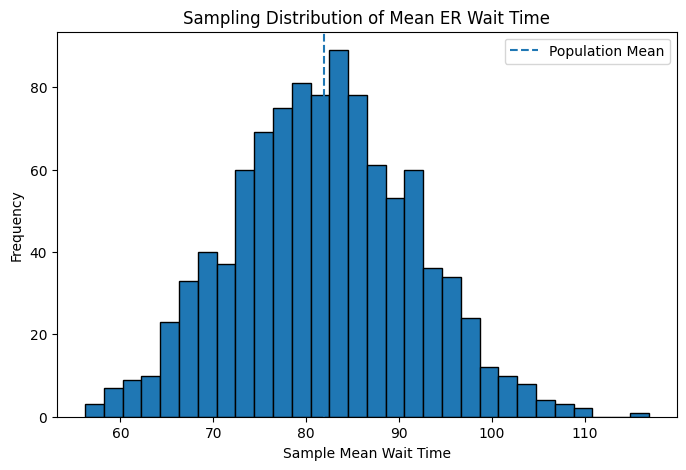

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30, edgecolor="black")
plt.axvline(population_mean, linestyle="--", label="Population Mean")
plt.title("Sampling Distribution of Mean ER Wait Time")
plt.xlabel("Sample Mean Wait Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
def confidence_interval_mean(data, confidence=0.95):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence
    critical_value = stats.t.ppf(1 - alpha / 2, df=n-1)

    margin_of_error = critical_value * se

    lower = mean - margin_of_error
    upper = mean + margin_of_error

    return mean, lower, upper, margin_of_error

In [ ]:
sample = df["total_wait_time_min"].sample(n=100, random_state=42)

mean, lower, upper, moe = confidence_interval_mean(sample)

print("Sample Mean:", mean)
print("95% Confidence Interval:", lower, "to", upper)
print("Margin of Error:", moe)

Sample Mean: 84.22
95% Confidence Interval: 70.62243277419414 to 97.81756722580586
Margin of Error: 13.597567225805857


In [ ]:
def bootstrap_ci(data, num_bootstrap=2000, confidence=0.95):
    data = np.array(data)
    bootstrap_means = []

    for i in range(num_bootstrap):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

    return np.mean(data), lower, upper, bootstrap_means

In [ ]:
mean, lower, upper, bootstrap_means = bootstrap_ci(df["total_wait_time_min"])

print("Bootstrap Mean:", mean)
print("95% Bootstrap CI:", lower, "to", upper)

Bootstrap Mean: 81.9166
95% Bootstrap CI: 80.0258 to 83.74294


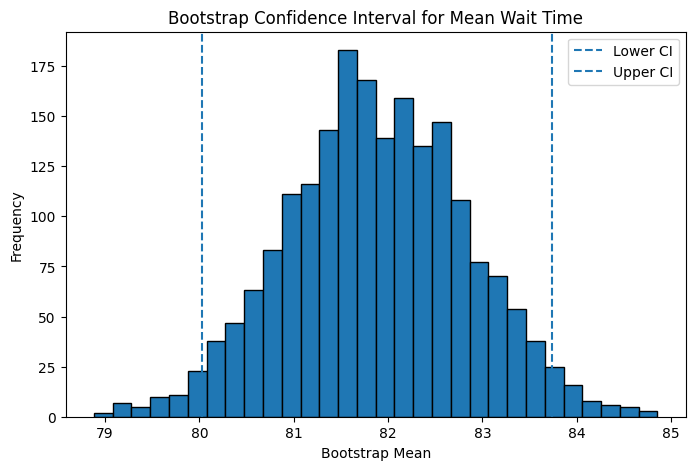

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=30, edgecolor="black")
plt.axvline(lower, linestyle="--", label="Lower CI")
plt.axvline(upper, linestyle="--", label="Upper CI")
plt.title("Bootstrap Confidence Interval for Mean Wait Time")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
def one_sample_t_test(data, hypothesized_mean):
    data = np.array(data)

    n = len(data)
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    se = sample_std / np.sqrt(n)

    t_stat = (sample_mean - hypothesized_mean) / se
    dfree = n - 1

    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=dfree))

    return {
        "sample_mean": sample_mean,
        "hypothesized_mean": hypothesized_mean,
        "t_stat": t_stat,
        "p_value": p_value,
        "degrees_of_freedom": dfree
    }

In [ ]:
one_sample_result = one_sample_t_test(df["total_wait_time_min"], 90)

one_sample_result

{'sample_mean': np.float64(81.9166),
 'hypothesized_mean': 90,
 't_stat': np.float64(-8.395190896581617),
 'p_value': np.float64(0.0),
 'degrees_of_freedom': 4999}

In [ ]:
if one_sample_result["p_value"] < 0.05:
    print("Reject H0: Average wait time is significantly different from 90 minutes.")
else:
    print("Fail to reject H0: Not enough evidence that average wait time differs from 90 minutes.")

Reject H0: Average wait time is significantly different from 90 minutes.


In [ ]:
urban = df[df["region"] == "Urban"]["total_wait_time_min"]
rural = df[df["region"] == "Rural"]["total_wait_time_min"]

print("Urban Mean:", urban.mean())
print("Rural Mean:", rural.mean())

Urban Mean: 81.97771124417831
Rural Mean: 81.82447342026079


In [ ]:
def two_sample_t_test(group1, group2):
    group1 = np.array(group1)
    group2 = np.array(group2)

    n1 = len(group1)
    n2 = len(group2)

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    se = np.sqrt((var1 / n1) + (var2 / n2))

    t_stat = (mean1 - mean2) / se

    numerator = ((var1 / n1) + (var2 / n2)) ** 2
    denominator = ((var1 / n1) ** 2 / (n1 - 1)) + ((var2 / n2) ** 2 / (n2 - 1))
    dfree = numerator / denominator

    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=dfree))

    return {
        "group1_mean": mean1,
        "group2_mean": mean2,
        "t_stat": t_stat,
        "p_value": p_value,
        "degrees_of_freedom": dfree
    }

In [ ]:
two_sample_result = two_sample_t_test(urban, rural)

two_sample_result

{'group1_mean': np.float64(81.97771124417831),
 'group2_mean': np.float64(81.82447342026079),
 't_stat': np.float64(0.07755035517762511),
 'p_value': np.float64(0.9381894293762001),
 'degrees_of_freedom': np.float64(4198.703896318126)}

In [ ]:
if two_sample_result["p_value"] < 0.05:
    print("Reject H0: Urban and Rural wait times are significantly different.")
else:
    print("Fail to reject H0: Not enough evidence of a difference.")

Fail to reject H0: Not enough evidence of a difference.


In [ ]:
stats.ttest_ind(urban, rural, equal_var=False)

TtestResult(statistic=np.float64(0.07755035517762511), pvalue=np.float64(0.9381894293762001), df=np.float64(4198.703896318126))

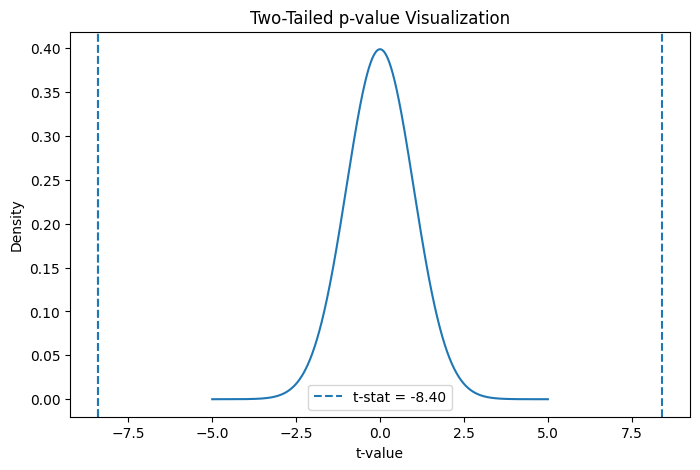

p-value: 0.0


In [ ]:
t_stat = one_sample_result["t_stat"]
dfree = one_sample_result["degrees_of_freedom"]

x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df=dfree)

plt.figure(figsize=(8, 5))
plt.plot(x, y)

plt.fill_between(
    x,
    y,
    where=(x <= -abs(t_stat)) | (x >= abs(t_stat)),
    alpha=0.4
)

plt.axvline(t_stat, linestyle="--", label=f"t-stat = {t_stat:.2f}")
plt.axvline(-abs(t_stat), linestyle="--")
plt.axvline(abs(t_stat), linestyle="--")

plt.title("Two-Tailed p-value Visualization")
plt.xlabel("t-value")
plt.ylabel("Density")
plt.legend()
plt.show()

print("p-value:", one_sample_result["p_value"])

In [ ]:
df.groupby("urgency_level")["total_wait_time_min"].mean()

,total_wait_time_min
urgency_level,
Critical,18.351047
High,43.187149
Low,173.536825
Medium,93.695585


In [ ]:
anova_model = smf.ols("total_wait_time_min ~ C(urgency_level)", data=df).fit()

anova_table = sm.stats.anova_lm(anova_model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(urgency_level),1.732277e+07,3.0,4931.221203,0.0
Residual,5.850112e+06,4996.0,NaN,NaN


In [ ]:
p_value_anova = anova_table["PR(>F)"][0]

if p_value_anova < 0.05:
    print("Reject H0: Wait time differs by urgency level.")
else:
    print("Fail to reject H0: No significant difference by urgency level.")

Reject H0: Wait time differs by urgency level.


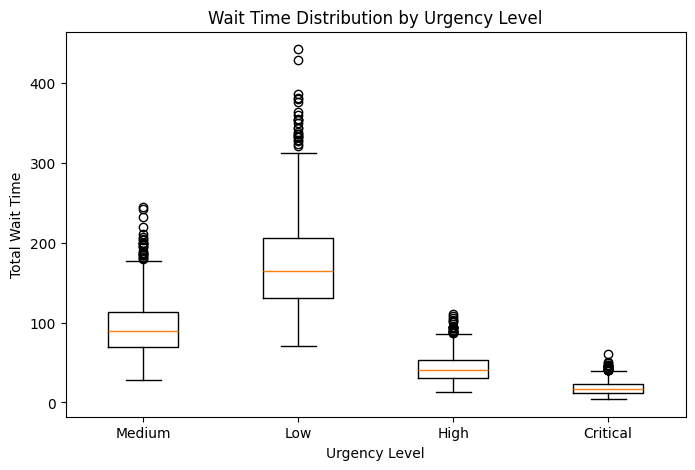

In [ ]:
plt.figure(figsize=(8, 5))

groups = [df[df["urgency_level"] == level]["total_wait_time_min"]
          for level in df["urgency_level"].unique()]

plt.boxplot(groups, labels=df["urgency_level"].unique())
plt.title("Wait Time Distribution by Urgency Level")
plt.xlabel("Urgency Level")
plt.ylabel("Total Wait Time")
plt.show()

In [ ]:
regression_features = [
    "time_to_registration_min",
    "time_to_triage_min",
    "time_to_medical_professional_min",
    "nurse_to_patient_ratio",
    "specialist_availability",
    "facility_size_beds"
]

X = df[regression_features].copy()
y = df["total_wait_time_min"].copy()

X.head()

,time_to_registration_min,time_to_triage_min,time_to_medical_professional_min,nurse_to_patient_ratio,specialist_availability,facility_size_beds
0,17,22,66,4,3,92
1,9,30,30,4,0,38
2,38,40,125,5,1,38
3,8,16,64,4,5,94
4,26,29,63,4,8,74


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 6)
(1000, 6)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_matrix = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_matrix = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

X_train_matrix[:5]

array([[ 1.        ,  0.21835828,  0.4932363 ,  1.13961402,  0.63274904,
        -0.94819645, -0.77462807],
       [ 1.        ,  0.31407698,  0.25064118,  2.73810797,  0.63274904,
         1.67339387, -0.01443503],
       [ 1.        ,  0.98410787,  0.45280378, -0.03822364,  0.63274904,
        -1.27589524, -0.8091823 ],
       [ 1.        ,  0.98410787,  1.09972407,  0.43852018,  1.46449277,
        -0.94819645,  0.43476995],
       [ 1.        ,  1.07982657,  0.81669644,  1.16765777,  1.46449277,
         2.00109266, -0.4463629 ]])

In [ ]:
beta = np.linalg.inv(X_train_matrix.T @ X_train_matrix) @ X_train_matrix.T @ y_train.values

beta

array([ 8.18827500e+01,  1.04472795e+01,  2.47325676e+01,  3.56585646e+01,
        3.44169138e-15,  1.33226763e-15, -1.77635684e-15])

In [ ]:
y_pred = X_test_matrix @ beta

y_pred[:10]

array([265.,   5.,  18.,  23.,  32.,  25.,   9.,  94.,  18.,  29.])

In [ ]:
def regression_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_total)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
scratch_metrics = regression_metrics(y_test, y_pred)

scratch_metrics

{'MAE': np.float64(4.169375955598298e-14),
 'MSE': np.float64(3.4098015645807945e-27),
 'RMSE': np.float64(5.839350618502706e-14),
 'R2': np.float64(1.0)}

In [ ]:
coef_table = pd.DataFrame({
    "feature": ["intercept"] + regression_features,
    "coefficient": beta
})

coef_table

,feature,coefficient
0,intercept,8.188275e+01
1,time_to_registration_min,1.044728e+01
2,time_to_triage_min,2.473257e+01
3,time_to_medical_professional_min,3.565856e+01
4,nurse_to_patient_ratio,3.441691e-15
5,specialist_availability,1.332268e-15
6,facility_size_beds,-1.776357e-15


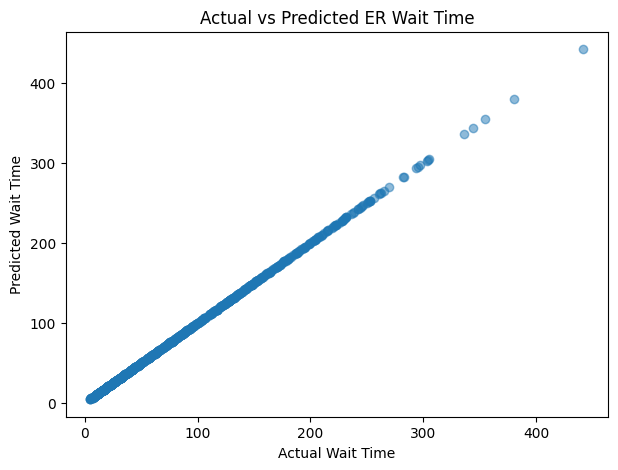

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.title("Actual vs Predicted ER Wait Time")
plt.show()

In [ ]:
formula = """
total_wait_time_min ~
time_to_registration_min +
time_to_triage_min +
time_to_medical_professional_min +
nurse_to_patient_ratio +
specialist_availability +
facility_size_beds +
C(region) +
C(urgency_level) +
C(time_of_day) +
C(season)
"""

ols_model = smf.ols(formula=formula, data=df).fit()

print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     total_wait_time_min   R-squared:                       1.000
Model:                             OLS   Adj. R-squared:                  1.000
Method:                  Least Squares   F-statistic:                 5.026e+31
Date:                 Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                         02:09:10   Log-Likelihood:             1.4009e+05
No. Observations:                 5000   AIC:                        -2.801e+05
Df Residuals:                     4982   BIC:                        -2.800e+05
Df Model:                           17                                         
Covariance Type:             nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [ ]:
ols_results = pd.DataFrame({
    "coefficient": ols_model.params,
    "p_value": ols_model.pvalues,
    "conf_low": ols_model.conf_int()[0],
    "conf_high": ols_model.conf_int()[1]
})

ols_results.sort_values("p_value").head(20)

,coefficient,p_value,conf_low,conf_high
time_to_medical_professional_min,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
time_to_registration_min,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
time_to_triage_min,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
facility_size_beds,-1.242062e-15,7.506374e-75,-1.372846e-15,-1.111278e-15
Intercept,7.283063e-14,9.541160e-12,5.192427e-14,9.373699e-14
C(region)[T.Urban],-4.618528e-14,1.614153e-07,-6.344307e-14,-2.892748e-14
C(season)[T.Summer],3.108624e-14,5.510987e-06,1.769010e-14,4.448239e-14
C(season)[T.Winter],3.197442e-14,1.346043e-05,1.758695e-14,4.636189e-14
nurse_to_patient_ratio,-1.953993e-14,3.390914e-05,-2.877211e-14,-1.030774e-14
C(urgency_level)[T.High],-3.907985e-14,6.790486e-04,-6.161302e-14,-1.654668e-14


In [ ]:
df["left_without_being_seen"] = (
    df["patient_outcome"] == "Left Without Being Seen"
).astype(int)

df["left_without_being_seen"].value_counts(normalize=True)

,proportion
left_without_being_seen,
0,0.9494
1,0.0506


In [ ]:
logit_formula = """
left_without_being_seen ~
total_wait_time_min +
nurse_to_patient_ratio +
specialist_availability +
facility_size_beds +
C(region) +
C(urgency_level) +
C(time_of_day) +
C(season)
"""

logit_model = smf.logit(formula=logit_formula, data=df).fit()

print(logit_model.summary())

         Current function value: 0.146840
         Iterations: 35
                              Logit Regression Results                             
Dep. Variable:     left_without_being_seen   No. Observations:                 5000
Model:                               Logit   Df Residuals:                     4984
Method:                                MLE   Df Model:                           15
Date:                     Sun, 21 Jun 2026   Pseudo R-squ.:                  0.2668
Time:                             02:09:39   Log-Likelihood:                -734.20
converged:                           False   LL-Null:                       -1001.4
Covariance Type:                 nonrobust   LLR p-value:                2.979e-104
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         -24.7116   4565.825     -0.0

In [ ]:
odds_ratios = np.exp(logit_model.params)

odds_table = pd.DataFrame({
    "coefficient": logit_model.params,
    "odds_ratio": odds_ratios,
    "p_value": logit_model.pvalues
})

odds_table.sort_values("p_value").head(20)

,coefficient,odds_ratio,p_value
total_wait_time_min,0.005732,1.005749e+00,0.001522
C(season)[T.Winter],0.561742,1.753725e+00,0.018677
C(time_of_day)[T.Early Morning],-0.884596,4.128807e-01,0.025834
nurse_to_patient_ratio,0.261397,1.298743e+00,0.060237
C(region)[T.Urban],0.212609,1.236901e+00,0.404071
C(time_of_day)[T.Late Morning],-0.130455,8.776964e-01,0.569544
C(season)[T.Summer],0.123402,1.131340e+00,0.581041
C(season)[T.Spring],0.101794,1.107155e+00,0.644100
facility_size_beds,-0.000473,9.995272e-01,0.808603
specialist_availability,-0.006840,9.931838e-01,0.812724


In [ ]:
logistic_features = [
    "total_wait_time_min",
    "nurse_to_patient_ratio",
    "specialist_availability",
    "facility_size_beds",
    "time_to_registration_min",
    "time_to_triage_min",
    "time_to_medical_professional_min"
]

X_log = df[logistic_features]
y_log = df["left_without_being_seen"]

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

y_pred_class = log_reg.predict(X_test_scaled)
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

print(classification_report(y_test, y_pred_class))

Accuracy: 0.944
ROC AUC: 0.87014194508151
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       949
           1       0.14      0.02      0.03        51

    accuracy                           0.94      1000
   macro avg       0.55      0.51      0.50      1000
weighted avg       0.91      0.94      0.92      1000



In [ ]:
confusion_matrix(y_test, y_pred_class)

array([[943,   6],
       [ 50,   1]])

In [ ]:
df.groupby("patient_satisfaction")["total_wait_time_min"].mean()

,total_wait_time_min
patient_satisfaction,
1,167.537711
2,88.747107
3,57.757159
4,27.697691
5,14.803604


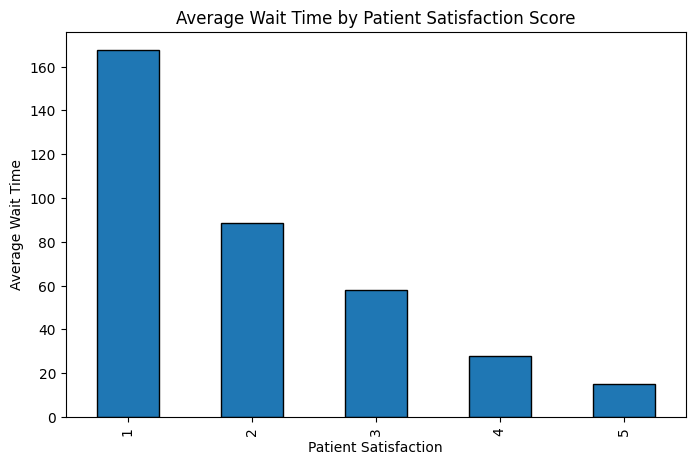

In [ ]:
plt.figure(figsize=(8, 5))
df.groupby("patient_satisfaction")["total_wait_time_min"].mean().plot(kind="bar", edgecolor="black")
plt.title("Average Wait Time by Patient Satisfaction Score")
plt.xlabel("Patient Satisfaction")
plt.ylabel("Average Wait Time")
plt.show()

In [ ]:
numeric_cols = [
    "total_wait_time_min",
    "time_to_registration_min",
    "time_to_triage_min",
    "time_to_medical_professional_min",
    "nurse_to_patient_ratio",
    "specialist_availability",
    "facility_size_beds",
    "patient_satisfaction"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,total_wait_time_min,time_to_registration_min,time_to_triage_min,time_to_medical_professional_min,nurse_to_patient_ratio,specialist_availability,facility_size_beds,patient_satisfaction
total_wait_time_min,1.000000,0.924238,0.953604,0.976446,0.688015,0.006579,-0.003578,-0.865145
time_to_registration_min,0.924238,1.000000,0.857030,0.876695,0.652054,0.006500,0.003402,-0.825610
time_to_triage_min,0.953604,0.857030,1.000000,0.875145,0.646690,-0.000512,-0.012659,-0.795599
time_to_medical_professional_min,0.976446,0.876695,0.875145,1.000000,0.673622,0.011028,0.000980,-0.857626
nurse_to_patient_ratio,0.688015,0.652054,0.646690,0.673622,1.000000,0.002511,0.002937,-0.738991
specialist_availability,0.006579,0.006500,-0.000512,0.011028,0.002511,1.000000,0.503209,-0.014892
facility_size_beds,-0.003578,0.003402,-0.012659,0.000980,0.002937,0.503209,1.000000,-0.010528
patient_satisfaction,-0.865145,-0.825610,-0.795599,-0.857626,-0.738991,-0.014892,-0.010528,1.000000


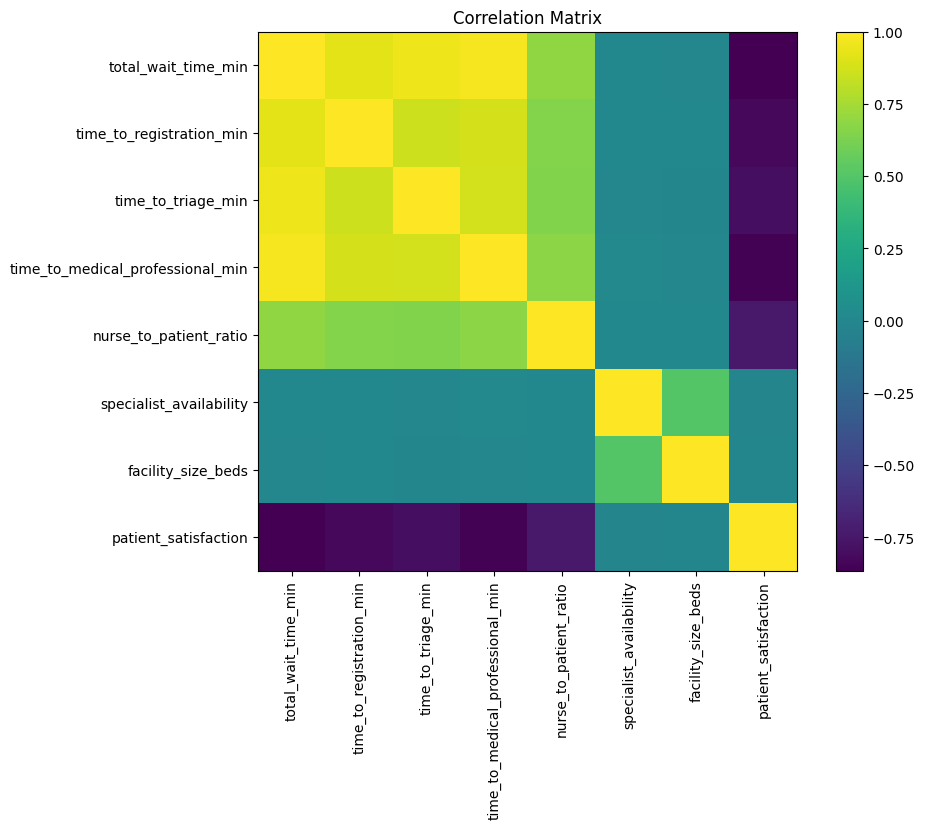

In [ ]:
plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
report = f"""
# ER Wait Time Statistical Inference and Regression Report

## Project Objective

The goal of this project is to analyze emergency room wait times using statistical inference, hypothesis testing, ANOVA, linear regression, and logistic regression.

## Dataset

The dataset contains simulated ER patient visit records. It includes hospital information, visit timing, urgency level, staffing indicators, wait-time components, patient outcome, and satisfaction score.

## Key Business Questions

1. What is the average ER wait time?
2. Do Urban and Rural hospitals have significantly different wait times?
3. Does urgency level affect wait time?
4. Which operational variables predict total wait time?
5. What factors increase the chance that a patient leaves without being seen?

## Confidence Interval Result

The estimated mean ER wait time is approximately {df["total_wait_time_min"].mean():.2f} minutes.

A bootstrap 95% confidence interval for mean wait time is:

{lower:.2f} to {upper:.2f} minutes.

## One-Sample Hypothesis Test

We tested whether the average wait time differs from 90 minutes.

p-value: {one_sample_result["p_value"]:.5f}

Conclusion:
{"Reject the null hypothesis. The average wait time is significantly different from 90 minutes." if one_sample_result["p_value"] < 0.05 else "Fail to reject the null hypothesis. There is not enough evidence that the average wait time differs from 90 minutes."}

## Two-Sample Hypothesis Test

We tested whether Urban and Rural hospitals have different average wait times.

Urban mean wait time: {urban.mean():.2f}
Rural mean wait time: {rural.mean():.2f}

p-value: {two_sample_result["p_value"]:.5f}

Conclusion:
{"Reject the null hypothesis. Urban and Rural hospitals have significantly different wait times." if two_sample_result["p_value"] < 0.05 else "Fail to reject the null hypothesis. There is not enough evidence of a difference between Urban and Rural wait times."}

## ANOVA

We tested whether wait time differs by urgency level.

ANOVA p-value: {p_value_anova:.5f}

Conclusion:
{"Reject the null hypothesis. At least one urgency group has a different average wait time." if p_value_anova < 0.05 else "Fail to reject the null hypothesis. Wait times do not significantly differ by urgency level."}

## Linear Regression

The linear regression model predicts total wait time using registration time, triage time, time to medical professional, staffing ratio, specialist availability, facility size, region, urgency level, time of day, and season.

R-squared: {ols_model.rsquared:.4f}

This means the model explains approximately {ols_model.rsquared * 100:.2f}% of the variation in total ER wait time.

## Logistic Regression

The logistic regression model predicts whether a patient leaves without being seen.

Important interpretation:
- Positive coefficients increase the log-odds of leaving without being seen.
- Negative coefficients decrease the log-odds.
- Odds ratios above 1 increase odds.
- Odds ratios below 1 decrease odds.

## Business Interpretation

Longer wait times are expected to reduce patient satisfaction and increase the probability of patients leaving without being seen.

Operationally, hospitals should focus on:
1. Reducing registration delays.
2. Reducing triage delays.
3. Improving nurse-to-patient ratios.
4. Increasing specialist availability during peak periods.
5. Monitoring high-volume days and time slots.

## Limitations

This dataset is simulated, not real patient data. Therefore, results should be interpreted as an educational analytics exercise rather than direct clinical evidence.
"""

print(report)


# ER Wait Time Statistical Inference and Regression Report

## Project Objective

The goal of this project is to analyze emergency room wait times using statistical inference, hypothesis testing, ANOVA, linear regression, and logistic regression.

## Dataset

The dataset contains simulated ER patient visit records. It includes hospital information, visit timing, urgency level, staffing indicators, wait-time components, patient outcome, and satisfaction score.

## Key Business Questions

1. What is the average ER wait time?
2. Do Urban and Rural hospitals have significantly different wait times?
3. Does urgency level affect wait time?
4. Which operational variables predict total wait time?
5. What factors increase the chance that a patient leaves without being seen?

## Confidence Interval Result

The estimated mean ER wait time is approximately 81.92 minutes.

A bootstrap 95% confidence interval for mean wait time is:

80.03 to 83.74 minutes.

## One-Sample Hypothesis Test

We tested 

In [ ]:
with open("model_interpretation_report.md", "w") as f:
    f.write(report)

files.download("model_interpretation_report.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>